# 00: Environment and Library Tour

This lesson prepares the ground for the DoWhy tutorial series. Before estimating any causal effect, we want students to know what is installed, what each major library is used for, where DoWhy fits in the causal workflow, and what kind of output to expect from a well-structured causal notebook.

The purpose is to build a reliable mental map: **causal question -> assumptions -> estimand -> estimate -> refutation -> cautious summary**.




## Orientation and Learning Goals

### What You Will Learn

By the end, you should be able to explain the role of each major tool in the local causal-inference environment, run a small DoWhy workflow without guessing what each step means, and understand how the remaining tutorial notebooks fit together.

We will cover:

- How to check the local Python and DoWhy environment.
- Which packages support effect estimation, graph work, machine learning, and plotting.
- The difference between an association and a causal effect.
- The main DoWhy workflow: `CausalModel`, `identify_effect`, `estimate_effect`, and `refute_estimate`.
- The second major DoWhy area: graphical causal models, often imported as `dowhy.gcm`.
- How the rest of this tutorial series is organized.

## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

This tutorial is an orientation to `DoWhy`, so the examples are deliberately compact. They are not meant to settle an applied causal question. They are meant to show how the package represents data, models, graphs, estimands, estimators, diagnostics, and saved outputs before the later notebooks use richer designs.

When a small dataset appears here, read it as a smoke test for the workflow rather than as evidence about a real population. The important experiment is procedural: can the environment run, can the objects be created, and can the reader see where assumptions will enter in later notebooks?


## Mathematical Foundation

<!-- math-foundation-note -->

DoWhy separates a causal workflow into estimand, identification, estimation, and refutation. The central estimand in many tutorials is

$$
\tau=\mathbb{E}\{Y(1)-Y(0)\}.
$$

Identification turns that counterfactual object into an observed-data expression. Estimation computes it from data. Refutation checks whether the conclusion is stable under changes that should not create a causal effect.


### How to Read This Tutorial Series

Each notebook in this folder should be read as a causal-analysis lesson, not as a bag of API snippets. The intended rhythm is:

1. State the causal question.
2. Describe the data and time ordering.
3. Write down the graph assumptions.
4. Identify the causal estimand.
5. Estimate the estimand with one or more statistical methods.
6. Stress-test the estimate.
7. Write down what the result does and does not support.

DoWhy is valuable because it forces the distinction between **identification** and **estimation**. Identification asks whether the causal quantity can be expressed from observed data under assumptions. Estimation asks how to compute that expression from a finite sample.

## Environment and Package Checks

This first code cell does a few practical things before importing plotting or causal libraries. It finds the repository root, creates local output folders, sets a writable Matplotlib cache directory, and imports common packages used across the tutorial series.

The Matplotlib cache setting is intentionally done before importing `matplotlib.pyplot`. Some environments have a non-writable home configuration folder, and this avoids distracting warnings in later notebooks.

In [1]:
from pathlib import Path
import importlib
import importlib.metadata as metadata
import os
import platform
import shutil
import sys
import warnings

# Find the repository root from either the repo root or the notebook folder.
START_DIR = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in [START_DIR, *START_DIR.parents] if (candidate / "pyproject.toml").exists()),
    START_DIR,
)

NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "dowhy"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
CACHE_DIR = PROJECT_ROOT / ".cache" / "matplotlib"

for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(CACHE_DIR))

# Keep student-facing output focused on causal concepts. These filters hide
# known third-party compatibility/deprecation warnings from the current package
# mix while leaving real execution errors visible.
warnings.filterwarnings("default")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")
warnings.filterwarnings("ignore", message=".*setParseAction.*deprecated.*")
warnings.filterwarnings("ignore", message=".*copy keyword is deprecated.*")
warnings.filterwarnings("ignore", message=".*disp.*iprint.*L-BFGS-B.*")
warnings.filterwarnings("ignore", module="dowhy.causal_estimators.regression_estimator")
warnings.filterwarnings("ignore", module="sklearn.linear_model._logistic")
warnings.filterwarnings("ignore", module="seaborn.categorical")
warnings.filterwarnings("ignore", module="pydot.dot_parser")

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)

# Compatibility shim for DoWhy estimators written against older pandas Series integer indexing.
if not getattr(pd.Series, "_dowhy_integer_position_patch", False):
    _original_series_getitem = pd.Series.__getitem__

    def _dowhy_series_getitem_compat(self, key):
        try:
            return _original_series_getitem(self, key)
        except KeyError:
            if isinstance(key, int) and key not in self.index:
                return self.iloc[key]
            raise

    pd.Series.__getitem__ = _dowhy_series_getitem_compat
    pd.Series._dowhy_integer_position_patch = True
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import statsmodels.formula.api as smf

from IPython.display import Markdown, display

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")

print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")
print(f"Repository root: {PROJECT_ROOT}")
print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


Python executable: /home/apex/Documents/portfolio/.venv/bin/python
Python version: 3.11.15
Repository root: /home/apex/Documents/portfolio
Notebook directory: /home/apex/Documents/portfolio/notebooks/tutorials/dowhy
Output directory: /home/apex/Documents/portfolio/notebooks/tutorials/dowhy/outputs


The important thing to check here is that the paths point where you expect. The tutorial writes small generated tables and figures under `notebooks/tutorials/dowhy/outputs`, which keeps tutorial outputs away from the applied project folders.


#### Warning and Compatibility Notes

This lesson suppresses known third-party compatibility and deprecation warnings so students can focus on the causal workflow. Runtime errors and unexpected failures are still visible. In production work, revisit warning filters periodically because they often signal libraries that should be upgraded together.

#### Package Version Snapshot

Causal notebooks are sensitive to package versions because libraries evolve quickly. The code below checks the packages that matter most for the DoWhy tutorials and labels each one by its role.

The `required_for` column is a practical teaching guide. A package can be installed and still be optional for a specific notebook, but this map tells you why it is in the environment.

In [2]:
# Save the artifacts produced by the Package Version Snapshot section.
package_roles = [
    ("dowhy", "core", "DoWhy workflows: graphs, identification, estimation, refutation, and GCM"),
    ("numpy", "core", "Numerical arrays and random simulation"),
    ("pandas", "core", "Tabular data manipulation"),
    ("scipy", "core", "Statistical and numerical utilities"),
    ("scikit-learn", "core", "Machine-learning models used by estimators and diagnostics"),
    ("statsmodels", "core", "Transparent regression baselines for learning"),
    ("networkx", "core", "Graph creation and visualization support"),
    ("matplotlib", "core", "Low-level plotting"),
    ("seaborn", "core", "Statistical plotting"),
    ("econml", "optional advanced", "Heterogeneous treatment effects and ML-based causal estimators"),
    ("causalml", "optional advanced", "Alternative uplift and causal ML estimators"),
    ("causal-learn", "optional advanced", "Causal discovery algorithms"),
    ("lightgbm", "optional advanced", "Fast tree models for nuisance functions"),
    ("xgboost", "optional advanced", "Boosted tree models for nuisance functions"),
    ("plotly", "optional", "Interactive visualization"),
]

rows = []
for package_name, role, required_for in package_roles:
    try:
        version = metadata.version(package_name)
        status = "installed"
    except metadata.PackageNotFoundError:
        version = None
        status = "missing"
    rows.append(
        {
            "package": package_name,
            "status": status,
            "version": version,
            "role": role,
            "required_for": required_for,
        }
    )

versions_df = pd.DataFrame(rows)
versions_df.to_csv(TABLE_DIR / "00_environment_package_versions.csv", index=False)
versions_df


,package,status,version,role,required_for
0,dowhy,installed,0.12,core,"DoWhy workflows: graphs, identification, estimation, refutation, and GCM"
1,numpy,installed,2.4.4,core,Numerical arrays and random simulation
2,pandas,installed,3.0.2,core,Tabular data manipulation
3,scipy,installed,1.17.1,core,Statistical and numerical utilities
4,scikit-learn,installed,1.6.1,core,Machine-learning models used by estimators and diagnostics
5,statsmodels,installed,0.14.6,core,Transparent regression baselines for learning
6,networkx,installed,3.6.1,core,Graph creation and visualization support
7,matplotlib,installed,3.10.9,core,Low-level plotting
8,seaborn,installed,0.13.2,core,Statistical plotting
9,econml,installed,0.16.0,optional advanced,Heterogeneous treatment effects and ML-based causal estimators


A healthy setup should show `dowhy` as installed. Optional advanced packages are useful later, but the first several tutorials mainly need DoWhy, pandas, NumPy, scikit-learn, statsmodels, NetworkX, Matplotlib, and Seaborn.

If a package is missing, install it in the project environment with `uv add <package-name>` and rerun this lesson from the top.

#### Import Check for DoWhy

The version table tells us whether the package is installed. The code below goes one step further: it imports the pieces we will use most often.

For the classic effect-estimation workflow, the central class is `CausalModel`. For graphical causal models, DoWhy exposes a separate namespace usually imported as `gcm`.

In [3]:
import networkx as nx

# Compatibility shim for DoWhy versions that expect the older NetworkX d_separated API.
if not hasattr(nx.algorithms, "d_separated"):
    from networkx.algorithms.d_separation import is_d_separator
    nx.algorithms.d_separated = is_d_separator

try:
    import dowhy
    from dowhy import CausalModel
    from dowhy import gcm
    gcm.config.disable_progress_bars()
    gcm.config.set_default_n_jobs(1)

    dowhy_import_status = {
        "dowhy_version": getattr(dowhy, "__version__", "unknown"),
        "CausalModel": "available",
        "gcm": "available",
    }
except Exception as exc:
    dowhy_import_status = {
        "dowhy_version": None,
        "CausalModel": "failed",
        "gcm": "failed",
        "error": repr(exc),
    }

pd.DataFrame([dowhy_import_status])


,dowhy_version,CausalModel,gcm
0,0.12,available,available


This is the main environment gate for the tutorial series. If `CausalModel` is available, the standard DoWhy causal-effect notebooks can run. If `gcm` is available, the later notebooks on graphical causal models, interventions, counterfactuals, and root-cause analysis can run too.

#### System Capability Check

Some visualization features in causal libraries can use external graph tools. The tutorials will avoid depending on system-level graph rendering when possible, but it is still useful to know what is available.

The code below checks for the Graphviz `dot` executable and a few Python modules that commonly appear in causal graph workflows.

In [4]:
# Define reusable helpers for the System Capability Check section.
def module_available(module_name):
    """
    Idea: Check whether an optional package can be imported before running an optional tutorial section.
    
    Parameters
    ----------
    module_name : object
        Readable label used in tables, plots, or saved outputs.
    
    Returns
    -------
    bool
        Whether the optional Python module can be imported in the current environment.
    """
    return importlib.util.find_spec(module_name) is not None

capability_rows = [
    {
        "capability": "Graphviz dot executable",
        "available": shutil.which("dot") is not None,
        "why_it_matters": "Helpful for rendering causal graphs from DOT strings.",
    },
    {
        "capability": "pydot Python module",
        "available": module_available("pydot"),
        "why_it_matters": "Often used to parse or write DOT graph files.",
    },
    {
        "capability": "pygraphviz Python module",
        "available": module_available("pygraphviz"),
        "why_it_matters": "Optional graph rendering integration; not required for this lesson.",
    },
    {
        "capability": "DoWhy GCM namespace",
        "available": "gcm" in globals(),
        "why_it_matters": "Needed for structural causal models, interventions, counterfactuals, and attribution tasks.",
    },
]

capability_df = pd.DataFrame(capability_rows)
capability_df.to_csv(TABLE_DIR / "00_environment_capabilities.csv", index=False)
capability_df


,capability,available,why_it_matters
0,Graphviz dot executable,True,Helpful for rendering causal graphs from DOT strings.
1,pydot Python module,True,Often used to parse or write DOT graph files.
2,pygraphviz Python module,False,Optional graph rendering integration; not required for this lesson.
3,DoWhy GCM namespace,True,"Needed for structural causal models, interventions, counterfactuals, and attribution tasks."


If Graphviz is unavailable, the core causal estimation workflow still works. We will use NetworkX plots in the tutorials so that students can see graphs without relying on extra system packages.

### DoWhy API Map

DoWhy contains two large families of functionality.

The first family is **effect inference**, centered around `CausalModel`. This is where you model a treatment-outcome question, identify an estimand, estimate it, and run refuters.

The second family is **graphical causal models**, centered around `dowhy.gcm`. This is where you fit causal mechanisms to graph nodes and then ask questions about interventions, counterfactuals, causal influence, anomaly attribution, and distribution changes.

In [5]:
# Fit or evaluate the model objects used in the DoWhy API Map section.
import inspect

causal_model_methods = [
    name
    for name, obj in inspect.getmembers(CausalModel, predicate=inspect.isfunction)
    if not name.startswith("_")
]

selected_gcm_names = [
    name
    for name in [
        "StructuralCausalModel",
        "InvertibleStructuralCausalModel",
        "ProbabilisticCausalModel",
        "auto",
        "fit",
        "draw_samples",
        "interventional_samples",
        "counterfactual_samples",
        "average_causal_effect",
        "arrow_strength",
        "intrinsic_causal_influence",
        "attribute_anomalies",
        "distribution_change",
        "evaluate_causal_model",
        "refute_causal_structure",
    ]
    if hasattr(gcm, name)
]

api_map = pd.DataFrame(
    [
        {
            "api_area": "CausalModel effect inference",
            "entry_point": "dowhy.CausalModel",
            "selected_available_methods": ", ".join(causal_model_methods),
        },
        {
            "api_area": "Graphical causal models",
            "entry_point": "dowhy.gcm",
            "selected_available_methods": ", ".join(selected_gcm_names),
        },
    ]
)

api_map.to_csv(TABLE_DIR / "00_dowhy_api_map.csv", index=False)
api_map


,api_area,entry_point,selected_available_methods
0,CausalModel effect inference,dowhy.CausalModel,"do, estimate_effect, get_common_causes, get_effect_modifiers, get_estimator, get_instruments, identify_effect, init_graph, interpret, learn_graph, refute_estimate, refute_graph, summary, view_model"
1,Graphical causal models,dowhy.gcm,"StructuralCausalModel, InvertibleStructuralCausalModel, ProbabilisticCausalModel, auto, fit, draw_samples, interventional_samples, counterfactual_samples, average_causal_effect, arrow_strength, intrinsic_causal_influence, attribute_anomalies, distribution_change, evaluate_causal_model, refute_causal_structure"


This table is a map, not something to memorize. In practice, the most important `CausalModel` methods at the beginning are `identify_effect`, `estimate_effect`, and `refute_estimate`. The most important GCM functions at the beginning are `auto.assign_causal_mechanisms`, `fit`, `draw_samples`, and `interventional_samples`.

### Tutorial Series Roadmap

This table turns the tutorial file names into a study plan. The sequence starts with the standard causal-effect workflow, then moves into identification strategies, robustness checks, graph discovery, graphical causal models, and reporting.

| notebook | main_question | level |
| --- | --- | --- |
| 00_environment_and_library_tour.ipynb | Orient to the environment and DoWhy API areas | Foundational |
| 01_core_workflow_model_identify_estimate_refute.ipynb | Run the standard model-identify-estimate-refute workflow | Foundational |
| 02_causal_graphs_dags_and_assumptions.ipynb | Use DAGs to express causal assumptions | Foundational |
| 03_backdoor_adjustment_and_confounding.ipynb | Handle observed confounding with backdoor adjustment | Foundational |
| 04_regression_matching_and_propensity_estimators.ipynb | Compare common estimators for one estimand | Foundational |
| 05_weighting_overlap_and_common_support.ipynb | Diagnose overlap and weighting fragility | Foundational |
| 06_frontdoor_iv_and_natural_experiments.ipynb | Study non-backdoor identification strategies | Intermediate |
| 07_cate_and_heterogeneous_effects.ipynb | Move from ATE to heterogeneous treatment effects | Intermediate |
| 08_refuters_placebos_negative_controls_sensitivity.ipynb | Stress-test estimates with refuters and sensitivity checks | Intermediate |
| 09_graph_discovery_and_graph_refutation.ipynb | Explore graph discovery and graph-level checks | Advanced |
| 10_gcm_structural_causal_models.ipynb | Fit graphical causal models | Advanced |
| 11_interventions_and_counterfactuals_with_gcm.ipynb | Ask intervention and counterfactual questions with GCM | Advanced |
| 12_mediation_direct_and_indirect_effects.ipynb | Separate direct and indirect pathways | Advanced |
| 13_root_cause_anomaly_and_distribution_change.ipynb | Use GCM for attribution and root-cause workflows | Advanced |
| 14_end_to_end_observational_case_study.ipynb | Assemble a full causal analysis | Capstone |
| 15_common_pitfalls_debugging_and_reporting.ipynb | Debug common mistakes and write transparent reports | Capstone |


The first six notebooks are the minimum path for students who want the core DoWhy workflow. The later notebooks cover specialized workflows that are useful once the basics are comfortable.

## A First DoWhy Causal Example

Before using DoWhy, we will create a small observational dataset where we know the true treatment effect. This is useful because it lets us separate three ideas:

- The **true causal effect** we used to generate the data.
- The **naive association** between treatment and outcome.
- The **adjusted causal estimate** after controlling for observed common causes.

The example imagines a binary product exposure, `feature_exposure`, and a later outcome, `weekly_value`. More engaged users are more likely to receive the exposure and also more likely to have high future value, so the raw treatment-outcome comparison is confounded.

In [6]:
# Define reusable helpers for the A Tiny Example Dataset section.
def make_teaching_data(n=2_500, seed=42):
    """
    Idea: Construct the example data used in the A Tiny Example Dataset section, including columns needed for later diagnostics.
    
    Parameters
    ----------
    n : int
        Number of observations or repetitions to generate.
    seed : int
        Random seed used to make generation or resampling reproducible.
    
    Returns
    -------
    tuple
        Tuple containing df, true_effect.
    """
    local_rng = np.random.default_rng(seed)

    user_engagement = local_rng.normal(loc=0.0, scale=1.0, size=n)
    prior_activity = np.clip(
        local_rng.poisson(lam=np.exp(1.0 + 0.25 * user_engagement), size=n),
        0,
        25,
    )
    account_age_weeks = local_rng.gamma(shape=2.0, scale=3.0, size=n)
    is_power_segment = local_rng.binomial(
        n=1,
        p=1 / (1 + np.exp(-(user_engagement - 0.3))),
        size=n,
    )

    treatment_logit = (
        -0.50
        + 0.85 * user_engagement
        + 0.045 * prior_activity
        + 0.45 * is_power_segment
        + 0.025 * account_age_weeks
    )
    treatment_probability = 1 / (1 + np.exp(-treatment_logit))
    feature_exposure = local_rng.binomial(n=1, p=treatment_probability, size=n)

    true_effect = 2.0
    weekly_value = (
        5.0
        + true_effect * feature_exposure
        + 1.30 * user_engagement
        + 0.08 * prior_activity
        + 0.50 * is_power_segment
        + 0.03 * account_age_weeks
        + local_rng.normal(loc=0.0, scale=1.0, size=n)
    )

    df = pd.DataFrame(
        {
            "feature_exposure": feature_exposure,
            "weekly_value": weekly_value,
            "user_engagement": user_engagement,
            "prior_activity": prior_activity,
            "is_power_segment": is_power_segment,
            "account_age_weeks": account_age_weeks,
            "treatment_probability": treatment_probability,
        }
    )
    return df, true_effect

teaching_df, TRUE_EFFECT = make_teaching_data()
teaching_df.to_csv(TABLE_DIR / "00_teaching_dataset_preview.csv", index=False)

print(f"Rows: {len(teaching_df):,}")
print(f"Known true treatment effect used in simulation: {TRUE_EFFECT:.2f}")
teaching_df.head()


Rows: 2,500
Known true treatment effect used in simulation: 2.00


,feature_exposure,weekly_value,user_engagement,prior_activity,is_power_segment,account_age_weeks,treatment_probability
0,1,6.816907,0.304717,0,0,7.128567,0.484311
1,0,5.300469,-1.039984,1,0,1.615020,0.214399
2,1,9.091265,0.750451,0,1,3.748515,0.664095
3,1,8.232119,0.940565,6,0,7.299610,0.679608
4,0,3.549568,-1.951035,0,0,2.943233,0.110583


The first rows show one unit per user-like observation. The treatment was not assigned randomly: it depends on user engagement, prior activity, account age, and segment. That is exactly why the naive treated-versus-control difference will not be the same as the true effect.

#### Data Dictionary

A good causal notebook should define every modeling column before using it. This avoids a common problem where a model runs successfully but the analyst has not clarified which variables are treatments, outcomes, confounders, mediators, instruments, or post-treatment variables.

| column | role | description |
| --- | --- | --- |
| feature_exposure | treatment | Binary indicator for receiving the feature or recommendation exposure. |
| weekly_value | outcome | Future user value measured after treatment assignment. |
| user_engagement | observed common cause | Pre-treatment engagement trait affecting both exposure and future value. |
| prior_activity | observed common cause | Pre-treatment activity count affecting both exposure and future value. |
| is_power_segment | observed common cause | Pre-treatment segment indicator affecting both exposure and future value. |
| account_age_weeks | observed common cause | Pre-treatment account age affecting both exposure and future value. |
| treatment_probability | known simulation diagnostic | The true treatment probability from the simulation; usually unavailable in real observational data. |


The main modeling variables are the treatment, outcome, and observed common causes. The `treatment_probability` column is included only because this is simulated example data. In real observational work, propensity scores usually have to be estimated.

#### Basic Data Checks

Before a causal model, run a few ordinary data checks. We want to know whether the treatment is reasonably common, whether the outcome has variation, and whether the covariates have plausible ranges.

In [7]:
summary_table = teaching_df.agg(
    {
        "feature_exposure": ["mean", "sum"],
        "weekly_value": ["mean", "std", "min", "max"],
        "user_engagement": ["mean", "std", "min", "max"],
        "prior_activity": ["mean", "std", "min", "max"],
        "is_power_segment": ["mean", "sum"],
        "account_age_weeks": ["mean", "std", "min", "max"],
        "treatment_probability": ["mean", "std", "min", "max"],
    }
).T

summary_table.to_csv(TABLE_DIR / "00_teaching_data_summary.csv")
summary_table


,mean,sum,std,min,max
feature_exposure,0.471600,1179.0,NaN,NaN,NaN
weekly_value,6.523774,NaN,2.332625,-0.567156,13.879695
user_engagement,-0.044328,NaN,1.005704,-3.648413,3.178854
prior_activity,2.745600,NaN,1.826202,0.000000,13.000000
is_power_segment,0.430000,1075.0,NaN,NaN,NaN
account_age_weeks,5.943010,NaN,4.252513,0.172814,29.188375
treatment_probability,0.485212,NaN,0.210476,0.033393,0.954910


The treatment rate should not be too close to zero or one, because causal comparisons become fragile when one treatment group is rare. The treatment-probability range also gives an early signal about overlap, which becomes a full topic in the weighting and common-support notebook.

### Treatment Assignment is Confounded

This plot shows why the example is observational rather than randomized. Users with higher pre-treatment engagement are more likely to receive the exposure, and they also tend to have higher future value even without the exposure.

That creates a backdoor path from treatment to outcome through engagement and other pre-treatment variables.

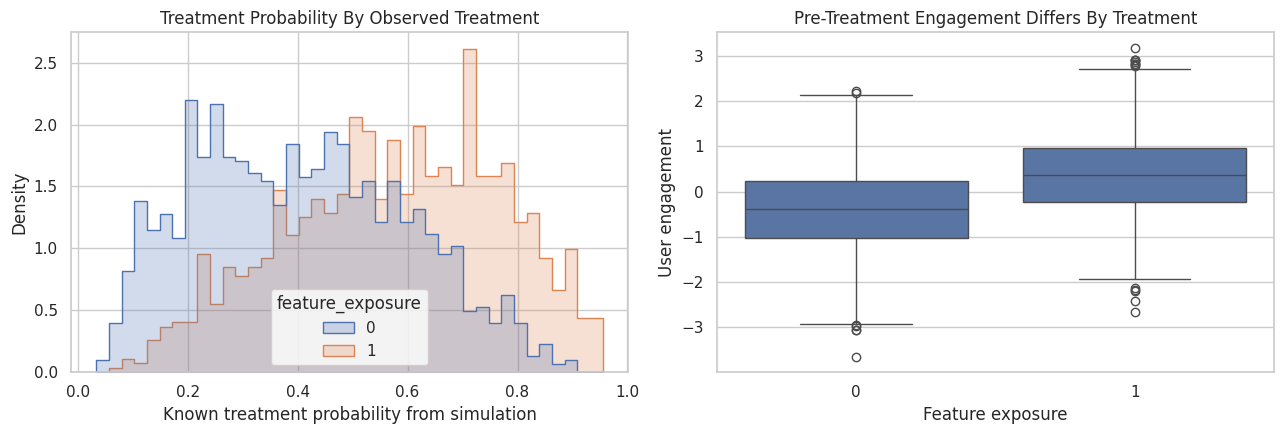

In [8]:
# Build and label the diagnostic visualization for the Treatment Assignment Is Confounded section.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(
    data=teaching_df,
    x="treatment_probability",
    hue="feature_exposure",
    bins=40,
    stat="density",
    common_norm=False,
    element="step",
    ax=axes[0],
)
axes[0].set_title("Treatment Probability By Observed Treatment")
axes[0].set_xlabel("Known treatment probability from simulation")
axes[0].set_ylabel("Density")

sns.boxplot(
    data=teaching_df,
    x="feature_exposure",
    y="user_engagement",
    ax=axes[1],
)
axes[1].set_title("Pre-Treatment Engagement Differs By Treatment")
axes[1].set_xlabel("Feature exposure")
axes[1].set_ylabel("User engagement")

plt.tight_layout()
fig.savefig(FIGURE_DIR / "00_treatment_assignment_checks.png", dpi=160, bbox_inches="tight")
plt.show()


The treated and untreated groups overlap, but they are not identical. Treated users tend to come from a higher-engagement part of the population. This is enough to make a raw difference in means misleading.

### Association versus Causal Effect

Now we compute three quantities side by side:

- The known true effect from the simulation.
- The naive treated-minus-control outcome difference.
- A transparent adjusted regression estimate that controls for the observed common causes.

This is not the full DoWhy workflow yet. It is a warm-up showing why a causal library is useful in the first place.

In [9]:
# Fit or evaluate the model objects used in the Association Versus Causal Effect section.
outcome_by_treatment = (
    teaching_df.groupby("feature_exposure")
    .agg(
        mean_weekly_value=("weekly_value", "mean"),
        rows=("weekly_value", "size"),
    )
    .reset_index()
)

naive_effect = (
    outcome_by_treatment.loc[outcome_by_treatment["feature_exposure"] == 1, "mean_weekly_value"].iloc[0]
    - outcome_by_treatment.loc[outcome_by_treatment["feature_exposure"] == 0, "mean_weekly_value"].iloc[0]
)

adjusted_model = smf.ols(
    formula=(
        "weekly_value ~ feature_exposure + user_engagement + prior_activity "
        "+ is_power_segment + account_age_weeks"
    ),
    data=teaching_df,
).fit()

adjusted_effect = adjusted_model.params["feature_exposure"]

association_comparison = pd.DataFrame(
    [
        {"quantity": "Known true effect from simulation", "value": TRUE_EFFECT},
        {"quantity": "Naive treated-minus-control difference", "value": naive_effect},
        {"quantity": "Adjusted OLS coefficient", "value": adjusted_effect},
    ]
)

association_comparison.to_csv(TABLE_DIR / "00_association_vs_adjusted_effect.csv", index=False)
association_comparison


,quantity,value
0,Known true effect from simulation,2.000000
1,Naive treated-minus-control difference,3.223284
2,Adjusted OLS coefficient,2.010912


The naive difference is larger than the true effect because treated users were already more engaged. The adjusted regression is much closer to the known effect because it blocks the observed backdoor paths in this teaching setup.

DoWhy gives us a structured way to make that adjustment logic explicit instead of hiding it inside a regression formula.

### The Causal Graph

A DoWhy workflow starts by declaring assumptions. Here the graph says that the four pre-treatment covariates affect both treatment and outcome, and the treatment affects the outcome.

The graph is not learned from the data in this lesson. It is the analyst's causal claim about how the data were generated.

In [10]:
causal_graph = """
digraph {
    user_engagement -> feature_exposure;
    user_engagement -> weekly_value;
    prior_activity -> feature_exposure;
    prior_activity -> weekly_value;
    is_power_segment -> feature_exposure;
    is_power_segment -> weekly_value;
    account_age_weeks -> feature_exposure;
    account_age_weeks -> weekly_value;
    feature_exposure -> weekly_value;
}
"""

print(causal_graph)



digraph {
    user_engagement -> feature_exposure;
    user_engagement -> weekly_value;
    prior_activity -> feature_exposure;
    prior_activity -> weekly_value;
    is_power_segment -> feature_exposure;
    is_power_segment -> weekly_value;
    account_age_weeks -> feature_exposure;
    account_age_weeks -> weekly_value;
    feature_exposure -> weekly_value;
}



The graph uses DOT syntax. The arrow `user_engagement -> feature_exposure` means engagement is assumed to cause or influence exposure assignment. The arrow `user_engagement -> weekly_value` means engagement is also assumed to influence the outcome.

Together, those two arrows make `user_engagement` a common cause that should be adjusted for.


## Model, Estimate, and Refute

#### Visualize the Graph without Extra System Dependencies

DoWhy can render graphs in some environments, but graph rendering often depends on optional system tools. For teaching, a simple NetworkX plot is enough to make the causal structure visible.

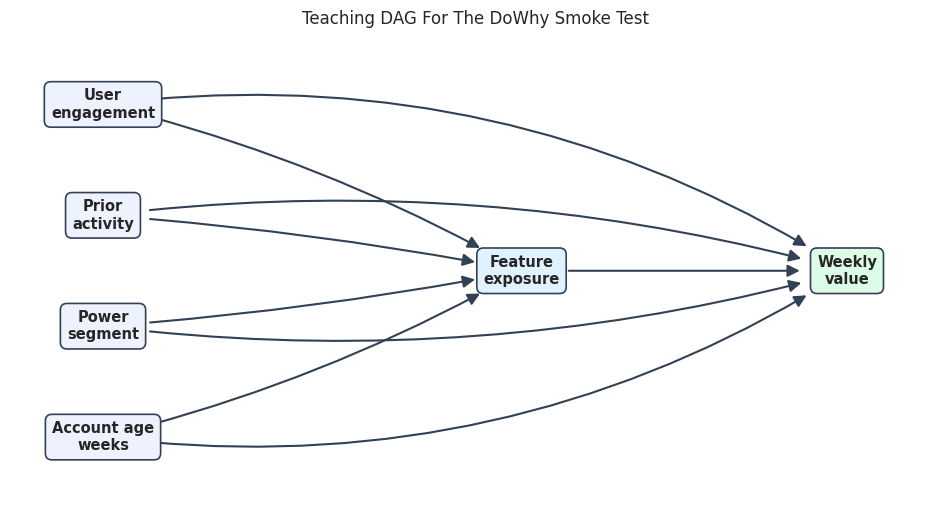

In [11]:
# Draw the DAG with explicit annotation arrows instead of relying on the
# default NetworkX edge renderer. This keeps arrowheads visible outside the
# large labeled boxes and makes the graph easier to read in exported notebooks.
graph_edges = [
    ("user_engagement", "feature_exposure"),
    ("user_engagement", "weekly_value"),
    ("prior_activity", "feature_exposure"),
    ("prior_activity", "weekly_value"),
    ("is_power_segment", "feature_exposure"),
    ("is_power_segment", "weekly_value"),
    ("account_age_weeks", "feature_exposure"),
    ("account_age_weeks", "weekly_value"),
    ("feature_exposure", "weekly_value"),
]

node_positions = {
    "user_engagement": (0.10, 0.88),
    "prior_activity": (0.10, 0.64),
    "is_power_segment": (0.10, 0.40),
    "account_age_weeks": (0.10, 0.16),
    "feature_exposure": (0.55, 0.52),
    "weekly_value": (0.90, 0.52),
}

node_labels = {
    "user_engagement": "User\nengagement",
    "prior_activity": "Prior\nactivity",
    "is_power_segment": "Power\nsegment",
    "account_age_weeks": "Account age\nweeks",
    "feature_exposure": "Feature\nexposure",
    "weekly_value": "Weekly\nvalue",
}

node_colors = {
    "user_engagement": "#eef2ff",
    "prior_activity": "#eef2ff",
    "is_power_segment": "#eef2ff",
    "account_age_weeks": "#eef2ff",
    "feature_exposure": "#e0f2fe",
    "weekly_value": "#dcfce7",
}

edge_radii = {
    ("user_engagement", "feature_exposure"): -0.07,
    ("prior_activity", "feature_exposure"): -0.03,
    ("is_power_segment", "feature_exposure"): 0.03,
    ("account_age_weeks", "feature_exposure"): 0.07,
    ("user_engagement", "weekly_value"): -0.18,
    ("prior_activity", "weekly_value"): -0.10,
    ("is_power_segment", "weekly_value"): 0.10,
    ("account_age_weeks", "weekly_value"): 0.18,
    ("feature_exposure", "weekly_value"): 0.00,
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_axis_off()

for source, target in graph_edges:
    ax.annotate(
        "",
        xy=node_positions[target],
        xytext=node_positions[source],
        arrowprops=dict(
            arrowstyle="-|>",
            color="#334155",
            linewidth=1.5,
            mutation_scale=18,
            shrinkA=34,
            shrinkB=34,
            connectionstyle=f"arc3,rad={edge_radii[(source, target)]}",
        ),
        zorder=1,
    )

for node, (x, y) in node_positions.items():
    ax.text(
        x,
        y,
        node_labels[node],
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.45",
            facecolor=node_colors[node],
            edgecolor="#334155",
            linewidth=1.2,
        ),
        zorder=2,
    )

ax.set_title("Teaching DAG For The DoWhy Smoke Test", pad=18)
fig.savefig(FIGURE_DIR / "00_teaching_dag.png", dpi=160, bbox_inches="tight")
plt.show()

The graph makes the adjustment problem visible. We want the effect of `feature_exposure` on `weekly_value`, but several pre-treatment variables point into both nodes. A credible estimate needs to handle those common causes.

#### Create a DoWhy CausalModel

The code below packages the data, treatment, outcome, and graph into a `CausalModel`. At this point DoWhy has not estimated the effect yet. It has only received the ingredients needed to reason about the causal problem.

In [12]:
model = CausalModel(
    data=teaching_df.drop(columns=["treatment_probability"]),
    treatment="feature_exposure",
    outcome="weekly_value",
    graph=causal_graph,
)

model_summary = {
    "treatment": model._treatment,
    "outcome": model._outcome,
    "common_causes_from_graph": model.get_common_causes(),
    "instruments_from_graph": model.get_instruments(),
    "effect_modifiers_from_graph": model.get_effect_modifiers(),
}

model_summary


{'treatment': ['feature_exposure'],
 'outcome': ['weekly_value'],
 'common_causes_from_graph': ['is_power_segment',
  'prior_activity',
  'user_engagement',
  'account_age_weeks'],
 'instruments_from_graph': [],
 'effect_modifiers_from_graph': []}

The detected common causes match the graph: engagement, activity, segment, and account age. There are no instruments or effect modifiers in this simple setup, which is expected because we did not draw those graph structures.

### Identify the Estimand

Identification is the step where DoWhy asks: under the graph assumptions, can the causal effect be written in terms of observed quantities?

For this graph, the answer should be a backdoor adjustment estimand: compare outcomes across treatment levels after conditioning on the observed common causes.

In [13]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|is_power_segment,prior_activity,user_engagem ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪                        
↪ ent,account_age_weeks])
↪                        
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,is_power_segment,prior_activity,user_engagement,account_age_weeks,U) = P(weekly_value|feature_exposure,is_power_segment,prior_activity,user_engagement,account_age_weeks)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



The printed estimand is verbose because DoWhy is exposing the assumptions rather than hiding them. The key idea is the unconfoundedness statement: after conditioning on the listed common causes, there should be no remaining unobserved common cause connecting treatment and outcome.

### Estimate the Effect

Now that the estimand is identified, we can estimate it. The code below uses DoWhy's linear-regression estimator for the backdoor estimand.

The estimator is statistical machinery. The causal claim still comes from the graph and identification assumptions.

In [14]:
linear_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.linear_regression",
)

print(linear_estimate)
print(f"Estimated effect value: {linear_estimate.value:.4f}")
print(f"Known true simulation effect: {TRUE_EFFECT:.4f}")

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                                                      ↪
──────────────────(E[weekly_value|is_power_segment,prior_activity,user_engagem ↪
d[featureₑₓₚₒₛᵤᵣₑ]                                                             ↪

↪                        
↪ ent,account_age_weeks])
↪                        
Estimand assumption 1, Unconfoundedness: If U→{feature_exposure} and U→weekly_value then P(weekly_value|feature_exposure,is_power_segment,prior_activity,user_engagement,account_age_weeks,U) = P(weekly_value|feature_exposure,is_power_segment,prior_activity,user_engagement,account_age_weeks)

## Realized estimand
b: weekly_value~feature_exposure+is_power_segment+prior_activity+user_engagement+account_age_weeks
Target units: ate

## Estimate
Mean value: 2.010911607745258

Estimated effect value: 2.0109
Known true simul

The DoWhy estimate should be close to the true effect because the example data were generated so that all common causes are observed and included in the graph. In real data, this agreement is not guaranteed because unobserved confounding and measurement error can remain.



### Compare Several Estimators for the Same Estimand

One of DoWhy's best habits is separating the estimand from the estimator. Once the effect is identified, we can estimate the same target with different methods and see whether the answers are stable.

Agreement across estimators is encouraging. Disagreement is a useful diagnostic signal.

In [15]:
# Save the artifacts produced by the Compare Several Estimators For The Same Estimand section.
estimator_specs = [
    ("linear_regression", "backdoor.linear_regression"),
    ("propensity_score_matching", "backdoor.propensity_score_matching"),
    ("propensity_score_stratification", "backdoor.propensity_score_stratification"),
    ("propensity_score_weighting", "backdoor.propensity_score_weighting"),
]

estimate_rows = []
for label, method_name in estimator_specs:
    try:
        estimate = model.estimate_effect(identified_estimand, method_name=method_name)
        estimate_rows.append(
            {
                "estimator": label,
                "method_name": method_name,
                "effect_estimate": float(estimate.value),
                "absolute_error_vs_true_effect": abs(float(estimate.value) - TRUE_EFFECT),
                "status": "ok",
            }
        )
    except Exception as exc:
        estimate_rows.append(
            {
                "estimator": label,
                "method_name": method_name,
                "effect_estimate": np.nan,
                "absolute_error_vs_true_effect": np.nan,
                "status": f"failed: {exc}",
            }
        )

estimator_comparison = pd.DataFrame(estimate_rows)
estimator_comparison.to_csv(TABLE_DIR / "00_estimator_comparison.csv", index=False)
estimator_comparison


,estimator,method_name,effect_estimate,absolute_error_vs_true_effect,status
0,linear_regression,backdoor.linear_regression,2.010912,0.010912,ok
1,propensity_score_matching,backdoor.propensity_score_matching,2.013006,0.013006,ok
2,propensity_score_stratification,backdoor.propensity_score_stratification,2.025420,0.025420,ok
3,propensity_score_weighting,backdoor.propensity_score_weighting,2.056975,0.056975,ok


The estimates will not be identical because each estimator uses different statistical machinery. For this simple example dataset, they should all point near the true effect. Later notebooks will explain when each estimator becomes fragile.

### Refute the Estimate

Refuters are sanity checks. They help catch estimates that behave in suspicious ways, while certification of causal validity still depends on the design.

The code below runs three basic checks:

- A placebo-treatment refuter replaces the real treatment with a fake one.
- A random-common-cause refuter adds an irrelevant random variable.
- A data-subset refuter checks whether the estimate is similar on random subsets.

In [16]:
# Save the artifacts produced by the Refute The Estimate section.
refuter_specs = [
    (
        "placebo_treatment_refuter",
        {
            "method_name": "placebo_treatment_refuter",
            "placebo_type": "permute",
            "num_simulations": 10,
        },
    ),
    (
        "random_common_cause",
        {
            "method_name": "random_common_cause",
            "num_simulations": 10,
        },
    ),
    (
        "data_subset_refuter",
        {
            "method_name": "data_subset_refuter",
            "subset_fraction": 0.80,
            "num_simulations": 10,
        },
    ),
]

refuter_results = []
for label, kwargs in refuter_specs:
    result = model.refute_estimate(identified_estimand, linear_estimate, **kwargs)
    refuter_results.append(
        {
            "refuter": label,
            "estimated_effect": float(result.estimated_effect),
            "new_effect": float(result.new_effect),
            "p_value": getattr(result, "refutation_result", {}).get("p_value") if hasattr(result, "refutation_result") else np.nan,
            "summary": str(result),
        }
    )

refuter_df = pd.DataFrame(refuter_results)
refuter_df.to_csv(TABLE_DIR / "00_refuter_results.csv", index=False)
refuter_df[["refuter", "estimated_effect", "new_effect", "p_value"]]


,refuter,estimated_effect,new_effect,p_value
0,placebo_treatment_refuter,2.010912,-0.018273,0.330642
1,random_common_cause,2.010912,2.010989,0.457404
2,data_subset_refuter,2.010912,2.011187,0.493546


The placebo effect should be close to zero, the random common cause should leave the estimate nearly unchanged, and the subset estimate should stay in the same neighborhood. These checks are simple and model an important habit: every causal estimate should face structured attempts to break it.



## GCM Preview and Next Steps

The classic `CausalModel` workflow estimates effects from a treatment-outcome design. DoWhy also includes graphical causal models, where each node in a graph gets a fitted causal mechanism.

This preview fits a tiny chain `x -> y -> z`, draws new samples from the fitted model, and then simulates an intervention that sets `y` to a constant. Later GCM notebooks will slow down and explain this in depth.

In [17]:
gcm.config.disable_progress_bars()
gcm.config.set_default_n_jobs(1)

gcm_rng = np.random.default_rng(RANDOM_SEED)
gcm_n = 800
x = gcm_rng.normal(0, 1, size=gcm_n)
y = 0.80 * x + gcm_rng.normal(0, 0.50, size=gcm_n)
z = 1.20 * y + gcm_rng.normal(0, 0.50, size=gcm_n)
gcm_data = pd.DataFrame({"x": x, "y": y, "z": z})

gcm_graph = nx.DiGraph([("x", "y"), ("y", "z")])
gcm_model = gcm.StructuralCausalModel(gcm_graph)
gcm.auto.assign_causal_mechanisms(
    gcm_model,
    gcm_data,
    quality=gcm.auto.AssignmentQuality.GOOD,
)
gcm.fit(gcm_model, gcm_data)

observational_draws = gcm.draw_samples(gcm_model, 5).assign(sample_type="drawn from fitted model")
intervention_draws = gcm.interventional_samples(
    gcm_model,
    {"y": lambda _old_value: 2.0},
    num_samples_to_draw=5,
).assign(sample_type="intervention: set y=2")

pd.concat([observational_draws, intervention_draws], ignore_index=True)


,x,y,z,sample_type
0,0.538034,-0.635036,-0.880686,drawn from fitted model
1,0.516298,-0.148774,-0.092592,drawn from fitted model
2,0.829519,0.860487,1.557840,drawn from fitted model
3,-0.863345,0.438523,1.438308,drawn from fitted model
4,0.270343,-0.461677,-0.516196,drawn from fitted model
5,-2.566658,2.000000,1.484506,intervention: set y=2
6,0.777792,2.000000,2.928897,intervention: set y=2
7,0.348776,2.000000,1.260846,intervention: set y=2
8,-0.337325,2.000000,2.651081,intervention: set y=2
9,-0.069138,2.000000,2.794261,intervention: set y=2


The intervention rows force `y` to equal `2`, and `z` responds through the fitted `y -> z` mechanism. This is a different style of causal question from the average-treatment-effect example above: it asks what samples would look like under an intervention on a node in a fitted causal mechanism graph.

### How the Two DoWhy Styles Fit Together

This table summarizes the difference between the two major DoWhy styles students will see in this folder.

| style | starting_point | typical_question | core_steps | tutorials |
| --- | --- | --- | --- | --- |
| Effect inference with CausalModel | Treatment, outcome, data, and causal graph | What is the effect of treatment A on outcome Y? | model -> identify -> estimate -> refute | 01 through 09, plus mediation and case-study notebooks |
| Graphical causal models with gcm | Graph structure and node-level causal mechanisms | What changes under interventions, counterfactuals, or anomalous mechanisms? | build graph -> assign mechanisms -> fit -> query the fitted model | 10 through 13 |


Students should learn the `CausalModel` workflow first because it teaches the discipline of assumptions, identification, estimation, and refutation. The GCM workflow is powerful, but it is easier to use responsibly after the basic causal language is comfortable.

### Practical Environment Fixes

When a causal notebook fails, the error is often environmental rather than causal. The code below writes a compact checklist that students can use before debugging model assumptions.

| symptom | likely_cause | first_fix |
| --- | --- | --- |
| DoWhy import fails | Package missing from the active environment | Run `uv add dowhy` from the repository root and restart the kernel. |
| Notebook uses a different Python than the terminal | Jupyter kernel is not pointing at the project virtual environment | Select the kernel created from this repository's `.venv` environment. |
| Graph rendering fails | Optional Graphviz system dependency is unavailable | Use NetworkX plots or install Graphviz if full DOT rendering is needed. |
| Estimator result changes every run | Random seed not fixed or stochastic estimator used | Set a random seed and document any stochastic settings. |
| CausalModel says effect is not identifiable | The graph does not support the requested estimand under observed variables | Inspect the graph, common causes, instruments, and time ordering before changing estimators. |


This checklist is intentionally practical. Do not start tuning estimators until the environment, kernel, graph, and variable roles are clear.

This is a reproducibility check rather than causal evidence. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Student Checkpoint

Before moving to the next notebook, you should be able to answer these questions in your own words:

- What does DoWhy mean by model, identify, estimate, and refute?
- Why is the naive treated-versus-control difference biased in the example data?
- Which variables were common causes in the graph?
- What did the refuters try to break?
- How is the `gcm` workflow different from the `CausalModel` workflow?

If those answers feel clear, continue to the core workflow notebook. If not, rerun the cells above and focus on the relationship between the graph, the estimand, and the estimator table.




## Reporting and Takeaways

#### Summary

The local environment is ready for a full DoWhy tutorial sequence. This lesson established the package map, created a controlled example dataset, showed why causal adjustment matters, ran a compact DoWhy effect-estimation workflow, previewed graphical causal models, and wrote reusable reference tables under the tutorial output folder.

The next notebook should slow down on the central DoWhy workflow and teach `CausalModel`, `identify_effect`, `estimate_effect`, and `refute_estimate` one step at a time.